SVM SOFT MARGIN

In [451]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(15)

# Clase +1
X1 = np.random.randn(30,2)*0.8 + np.array([1.2,1.2])

# Clase -1
X2 = np.random.randn(30,2)*0.8 + np.array([-1.2,-1.2])

X = np.vstack((X1,X2))

t = np.hstack((np.ones(30),-np.ones(30)))
X.shape,t.shape

((60, 2), (60,))

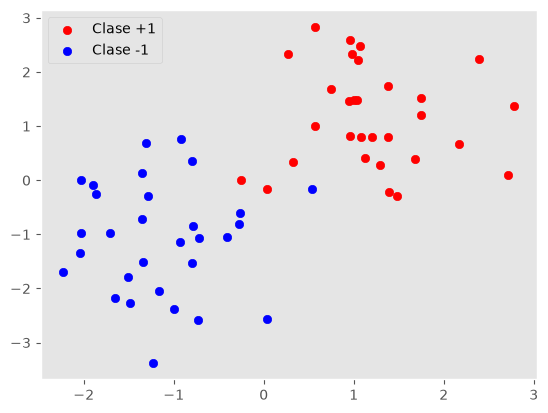

In [452]:
plt.scatter(X1[:,0],X1[:,1], color="red",label="Clase +1")
plt.scatter(X2[:,0],X2[:,1], color="blue",label="Clase -1")
plt.grid()
plt.legend()
plt.show()            

In [453]:
def kernel(X):
    return X@X.T

In [454]:
K= kernel(X)
z=np.outer(t,t)*K
alphas=np.random.rand(len(t))
C=0.5


In [455]:
def objetivo(alphas):
    return 0.5*alphas@z@alphas - np.sum(alphas)

In [456]:
cons=[{"type":"eq","fun": lambda alphas: np.sum(alphas*t)}]
bounds=[(0,C)]*len(alphas)

In [457]:
opt=minimize(objetivo, alphas, constraints=cons, bounds=bounds)
a=opt.x

In [458]:
sv=(a>1e-5) & (a<C-(1e-5))

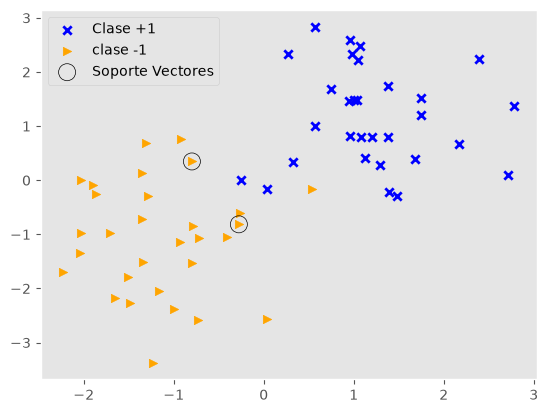

In [459]:
plt.scatter(X1[:,0],X1[:,1], color='blue', marker='x', label='Clase +1')
plt.scatter(X2[:,0],X2[:,1], color="orange", marker=">", label="clase -1")
plt.scatter(X[sv,0],X[sv,1], s=150,edgecolors='black' , facecolor="none",label="Soporte Vectores")
plt.legend()
plt.grid()
plt.show()

In [460]:
w=np.sum((a*t)[:,None]*X,axis=0)
b=np.mean(t[sv]-X[sv]@w)

In [461]:
x1 = np.linspace(-4,4,100)
x2=(-w[0]*x1-b)/w[1]
y_sup = (-w[0]*x1-b+1)/w[1]
y_inf = (-w[0]*x1-b-1)/w[1]

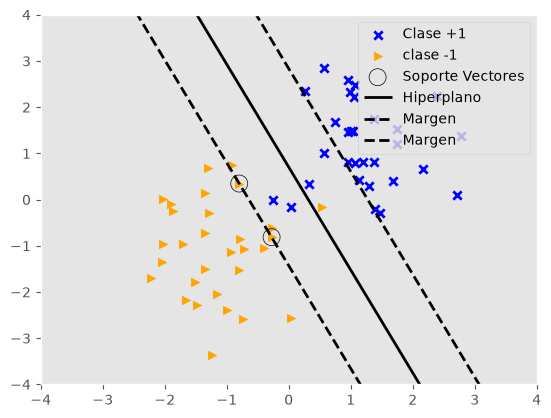

In [462]:
plt.scatter(X1[:,0],X1[:,1], color='blue', marker='x', label='Clase +1')
plt.scatter(X2[:,0],X2[:,1], color="orange", marker=">", label="clase -1")
plt.scatter(X[sv,0],X[sv,1], s=150,edgecolors='black' , facecolor="none",label="Soporte Vectores")
plt.plot(x1,x2, color="black", label="Hiperplano")
plt.plot(x1,y_sup, color="black", linestyle='--', label="Margen")
plt.plot(x1,y_inf, color="black", linestyle='--', label="Margen")

plt.xlim(-4,4)
plt.ylim(-4,4)
plt.legend()
plt.grid()
plt.show()